# Model #

I try to put down a model. I will use the xor-perceptron model as a base and modify that.

first create the lattice, N by N, with Nsol = N**2

I should create a class for the cell object and then the network class is formed by cell objects and when the network is created, each network is associated with a position in the lattice.

Note: for now I'm only considering one possible link between each pair neuron for each direction

In [1]:
import numpy as np
from numpy import random as nrd
import matplotlib.pyplot as plt
import graph_tool as gt
from graph_tool.all import *

import model as m       # I've put all the functions in a separate Python file


(ipykernel_launcher.py:116048): dbind-WARNING **: 15:18:07.683: AT-SPI: Error retrieving accessibility bus address: org.freedesktop.DBus.Error.ServiceUnknown: The name org.a11y.Bus was not provided by any .service files


In [2]:
# parameters of the simulation
par={'N': 2,                    # side length of the squared lattice
     'int_range': 1,             # interaction range
     'p_self_link': 0,         # probability for each cell of having a self link
     'J_range': [-1,+1],                       # define the possible value for J.
     'J_mutation_radius': 0.1,                 # standard deviation of the normal distribution used to sample the mutation value for J.
     'B_mutation_radius': 0.1,            # standard deviation of the normal distribution used to sample the mutation value for B.
     'T_mutation_radius': 0.1,           # standard deviation of the normal distribution used to sample the mutation value for T.
     'reproduction_ratio': 0.8,          # percentage of offsprings to be generated by reproduction (the reamining by random generation)
     'length_powerlaw': 1,         # exponent of the wire length power law (DA DEFINIRE!!!)
     'x_n': np.linspace(-1,1,32),   # discretization of the input of the transfer function (last argmument 
                                   # is also the maximum number of non-zero coefficients in the DFT of the 
                                   # transfer function. it should be a power of 2 for best performance of fft)
     'T_initial': lambda x: 0 + 1*x,              # initial transfer function shape (here linear)
     'target_set': [0.0,1.0,1.0,0.0],
     'input_set':[[0,0],[0,1],[1,0],[1,1]],
     'n_iter': 10,
     'N_sol': 10}                       # number of solutions (individuals, networks) considered in the simulation

#nrd.seed(1234)

In [3]:
n_parents = int(np.floor(par['N_sol'] * par['reproduction_ratio'])-np.floor(par['N_sol'] * par['reproduction_ratio'])%2)
n_parents

8

In [4]:
sol, fmean = m.evolution(par,verb=3,gen_verb=False)

f_n shape:(32,)
f_n:[-1.         -0.93548387 -0.87096774 -0.80645161 -0.74193548 -0.67741935
 -0.61290323 -0.5483871  -0.48387097 -0.41935484 -0.35483871 -0.29032258
 -0.22580645 -0.16129032 -0.09677419 -0.03225806  0.03225806  0.09677419
  0.16129032  0.22580645  0.29032258  0.35483871  0.41935484  0.48387097
  0.5483871   0.61290323  0.67741935  0.74193548  0.80645161  0.87096774
  0.93548387  1.        ]
T shape: (17,)
T_complete shape:(4, 17)
T_complete:[[-8.88178420e-16 +0.j         -1.03225806e+00+10.48069201j
  -1.03225806e+00 +5.18951173j -1.03225806e+00 +3.4028988j
  -1.03225806e+00 +2.49209142j -1.03225806e+00 +1.93121901j
  -1.03225806e+00 +1.54488337j -1.03225806e+00 +1.25781009j
  -1.03225806e+00 +1.03225806j -1.03225806e+00 +0.8471523j
  -1.03225806e+00 +0.68973279j -1.03225806e+00 +0.55175343j
  -1.03225806e+00 +0.42757529j -1.03225806e+00 +0.31313206j
  -1.03225806e+00 +0.2053289j  -1.03225806e+00 +0.10166855j
  -1.03225806e+00 +0.j        ]
 [-8.88178420e-16 +0.j      

In [5]:
f_n = par['T_initial'](par['x_n'])
F = np.fft.rfft(f_n,n=len(par['x_n'])+1)
F = np.tile(F,par['N']**2).reshape(par['N']**2,len(F))
print(F.shape)
print(F)

(4, 17)
[[-7.77156117e-16 +0.j         -2.10979506e+00+10.94665626j
  -2.05277877e+00 +5.12759347j -1.96004408e+00 +3.04988813j
  -1.83494269e+00 +1.9244325j  -1.68199607e+00 +1.19774398j
  -1.50673211e+00 +0.6881015j  -1.31548532e+00 +0.31913329j
  -1.11516785e+00 +0.05312199j -9.13019688e-01 -0.13127241j
  -7.16347007e-01 -0.24793011j -5.32258065e-01 -0.30729934j
  -3.67406315e-01 -0.31835938j -2.27749931e-01 -0.2896076j
  -1.18336458e-01 -0.2295407j  -4.31203829e-02 -0.14685454j
  -4.82021145e-03 -0.05047954j]
 [-7.77156117e-16 +0.j         -2.10979506e+00+10.94665626j
  -2.05277877e+00 +5.12759347j -1.96004408e+00 +3.04988813j
  -1.83494269e+00 +1.9244325j  -1.68199607e+00 +1.19774398j
  -1.50673211e+00 +0.6881015j  -1.31548532e+00 +0.31913329j
  -1.11516785e+00 +0.05312199j -9.13019688e-01 -0.13127241j
  -7.16347007e-01 -0.24793011j -5.32258065e-01 -0.30729934j
  -3.67406315e-01 -0.31835938j -2.27749931e-01 -0.2896076j
  -1.18336458e-01 -0.2295407j  -4.31203829e-02 -0.14685454j
  

In [6]:
type(F[0,0])

numpy.complex128

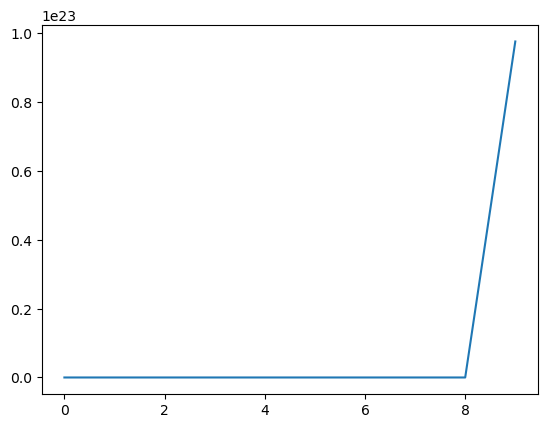

In [7]:
plt.plot(fmean)

In [8]:
n1 = m.generate(par)
n2 = m.generate(par)

o1, o2 = m.crossover(n1,n2)

f_n shape:(32,)
f_n:[-1.         -0.93548387 -0.87096774 -0.80645161 -0.74193548 -0.67741935
 -0.61290323 -0.5483871  -0.48387097 -0.41935484 -0.35483871 -0.29032258
 -0.22580645 -0.16129032 -0.09677419 -0.03225806  0.03225806  0.09677419
  0.16129032  0.22580645  0.29032258  0.35483871  0.41935484  0.48387097
  0.5483871   0.61290323  0.67741935  0.74193548  0.80645161  0.87096774
  0.93548387  1.        ]
T shape: (17,)
T_complete shape:(4, 17)
T_complete:[[-8.88178420e-16 +0.j         -1.03225806e+00+10.48069201j
  -1.03225806e+00 +5.18951173j -1.03225806e+00 +3.4028988j
  -1.03225806e+00 +2.49209142j -1.03225806e+00 +1.93121901j
  -1.03225806e+00 +1.54488337j -1.03225806e+00 +1.25781009j
  -1.03225806e+00 +1.03225806j -1.03225806e+00 +0.8471523j
  -1.03225806e+00 +0.68973279j -1.03225806e+00 +0.55175343j
  -1.03225806e+00 +0.42757529j -1.03225806e+00 +0.31313206j
  -1.03225806e+00 +0.2053289j  -1.03225806e+00 +0.10166855j
  -1.03225806e+00 +0.j        ]
 [-8.88178420e-16 +0.j      